# Statistical Tests — Análisis de significancia

**Objetivo:** Determinar si las features tienen relación estadísticamente significativa con la TARGET.

En este notebook:
1. Chi-Square test para categóricas
2. Mann-Whitney U test para numéricas
3. Correlación Spearman con TARGET
4. Consolidación de resultados

Con 307K muestras, el test tiene tanto poder que detecta hasta diferencias microscópicas. Por eso necesitamos **dos filtros**:

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

---
## 2. Carga de datos

In [2]:
df = pd.read_csv('../data/processed/application_train_preprocessed.csv')

TARGET_COL = 'TARGET'
ID_COL = 'SK_ID_CURR'

print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Features: {df.shape[1] - 2}')
print()
print(f'Target:')
print(df[TARGET_COL].value_counts())

Dataset: 307,511 filas x 219 columnas
Features: 217

Target:
TARGET
0    282686
1     24825
Name: count, dtype: int64


---
## 3. Separar categóricas de numéricas

Después del preprocessing, todo es numérico. Pero para los tests necesitamos distinguir:

- **Categóricas:** 2-20 valores únicos 
- **Numéricas continuas:** >20 valores únicos 

In [3]:
all_features = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]

cat_features = []
num_features = []

for col in all_features:
    if df[col].nunique() <= 20:
        cat_features.append(col)
    else:
        num_features.append(col)

print(f'Categóricas (≤20 vals): {len(cat_features)}')
for c in cat_features:
    print(f'  {c}')
print()
print(f'Numéricas (>20 vals):   {len(num_features)}')
for c in num_features:
    print(f'  {c}')

Categóricas (≤20 vals): 96
  CNT_CHILDREN
  NAME_EDUCATION_TYPE
  FLAG_MOBIL
  FLAG_EMP_PHONE
  FLAG_WORK_PHONE
  FLAG_CONT_MOBILE
  FLAG_PHONE
  FLAG_EMAIL
  OCCUPATION_TYPE
  CNT_FAM_MEMBERS
  REGION_RATING_CLIENT
  REGION_RATING_CLIENT_W_CITY
  WEEKDAY_APPR_PROCESS_START
  REG_REGION_NOT_LIVE_REGION
  REG_REGION_NOT_WORK_REGION
  LIVE_REGION_NOT_WORK_REGION
  REG_CITY_NOT_LIVE_CITY
  REG_CITY_NOT_WORK_CITY
  LIVE_CITY_NOT_WORK_CITY
  DEF_30_CNT_SOCIAL_CIRCLE
  DEF_60_CNT_SOCIAL_CIRCLE
  FLAG_DOCUMENT_2
  FLAG_DOCUMENT_3
  FLAG_DOCUMENT_4
  FLAG_DOCUMENT_5
  FLAG_DOCUMENT_6
  FLAG_DOCUMENT_7
  FLAG_DOCUMENT_8
  FLAG_DOCUMENT_9
  FLAG_DOCUMENT_10
  FLAG_DOCUMENT_11
  FLAG_DOCUMENT_12
  FLAG_DOCUMENT_13
  FLAG_DOCUMENT_14
  FLAG_DOCUMENT_15
  FLAG_DOCUMENT_16
  FLAG_DOCUMENT_17
  FLAG_DOCUMENT_18
  FLAG_DOCUMENT_19
  FLAG_DOCUMENT_20
  FLAG_DOCUMENT_21
  AMT_REQ_CREDIT_BUREAU_HOUR
  AMT_REQ_CREDIT_BUREAU_DAY
  AMT_REQ_CREDIT_BUREAU_WEEK
  AMT_REQ_CREDIT_BUREAU_QRT
  CNT_CREDIT_PROLONG_

---
## 4. Chi-Square Test — Categóricas

Compara la distribución de una categórica entre TARGET=0 y TARGET=1.

In [4]:
chi2_results = []

for col in cat_features:
    # Crear tabla de contingencia
    contingency = pd.crosstab(df[col], df[TARGET_COL])
    
    # Chi-Square test
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    
    # Cramér's V 
    n = len(df)
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    chi2_results.append({
        'Feature': col,
        'Chi2': chi2,
        'P_value': p,
        'Cramers_V': cramers_v,
        'Significativa': 'Sí' if p < 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('P_value')

print('CHI-SQUARE TEST — Resultados')
print('=' * 70)
print(f'Total features testeadas: {len(chi2_df)}')
print(f'Significativas (p<0.05):  {(chi2_df["P_value"] < 0.05).sum()}')
print(f'No significativas:         {(chi2_df["P_value"] >= 0.05).sum()}')
print()
chi2_df.head(20)

CHI-SQUARE TEST — Resultados
Total features testeadas: 96
Significativas (p<0.05):  64
No significativas:         32



,Feature,Chi2,P_value,Cramers_V,Significativa
11,REGION_RATING_CLIENT_W_CITY,1143.446338,5.055715e-249,0.060979,Sí
8,OCCUPATION_TYPE,1193.394739,3.420352e-243,0.062296,Sí
10,REGION_RATING_CLIENT,1067.192692,1.828316e-232,0.058910,Sí
69,NAME_INCOME_TYPE_Working,1015.620789,7.225960e-223,0.057469,Sí
1,NAME_EDUCATION_TYPE,1019.213187,2.447681e-219,0.057571,Sí
51,CODE_GENDER_M,920.103847,4.183493e-202,0.054700,Sí
17,REG_CITY_NOT_WORK_CITY,799.218045,7.981277e-176,0.050980,Sí
65,NAME_INCOME_TYPE_Pensioner,656.190130,1.006676e-144,0.046194,Sí
3,FLAG_EMP_PHONE,649.751181,2.530606e-143,0.045967,Sí
16,REG_CITY_NOT_LIVE_CITY,605.481659,1.075235e-133,0.044373,Sí


In [5]:
# Filtrar por significancia estadística Y tamaño de efecto
chi2_df['Util_practica'] = (chi2_df['P_value'] < 0.05) & (chi2_df['Cramers_V'] >= 0.1)

print('CHI-SQUARE — Desglose de resultados')
print('=' * 70)
print(f'Total testeadas:                    {len(chi2_df)}')
print(f'Significativas (p<0.05):            {(chi2_df["P_value"] < 0.05).sum()}')
print(f'Significativas Y útiles (V≥0.1):    {chi2_df["Util_practica"].sum()}')
print(f'Significativas pero NO útiles:      {(chi2_df["P_value"] < 0.05).sum() - chi2_df["Util_practica"].sum()}')
print(f'No significativas:                   {(chi2_df["P_value"] >= 0.05).sum()}')
print()

# Mostrar ruido
ruido = chi2_df[(chi2_df['P_value'] < 0.05) & (chi2_df['Cramers_V'] < 0.1)]
if len(ruido) > 0:
    print(f'Features significativas pero NO útiles ({len(ruido)}):')
    print('(candidatas a eliminar por falta de utilidad práctica)')
    print()
    for _, row in ruido.iterrows():
        print(f'  {row["Feature"]:45s} p={row["P_value"]:.4f}  V={row["Cramers_V"]:.4f}')



CHI-SQUARE — Desglose de resultados
Total testeadas:                    96
Significativas (p<0.05):            64
Significativas Y útiles (V≥0.1):    0
Significativas pero NO útiles:      64
No significativas:                   32

Features significativas pero NO útiles (64):
(candidatas a eliminar por falta de utilidad práctica)

  REGION_RATING_CLIENT_W_CITY                   p=0.0000  V=0.0610
  OCCUPATION_TYPE                               p=0.0000  V=0.0623
  REGION_RATING_CLIENT                          p=0.0000  V=0.0589
  NAME_INCOME_TYPE_Working                      p=0.0000  V=0.0575
  NAME_EDUCATION_TYPE                           p=0.0000  V=0.0576
  CODE_GENDER_M                                 p=0.0000  V=0.0547
  REG_CITY_NOT_WORK_CITY                        p=0.0000  V=0.0510
  NAME_INCOME_TYPE_Pensioner                    p=0.0000  V=0.0462
  FLAG_EMP_PHONE                                p=0.0000  V=0.0460
  REG_CITY_NOT_LIVE_CITY                        p=0.0000  V=0.04

In [6]:
# Features NO significativas
no_sig = chi2_df[chi2_df['P_value'] >= 0.05]

if len(no_sig) > 0:
    print(f'{len(no_sig)} features NO significativas (p ≥ 0.05):')
    print('Candidatas a eliminar en Feature Selection.')
    print()
    for _, row in no_sig.iterrows():
        print(f'  {row["Feature"]:45s} p={row["P_value"]:.4f}  CramérV={row["Cramers_V"]:.4f}')
else:
    print(' Todas las categóricas son significativas.')

32 features NO significativas (p ≥ 0.05):
Candidatas a eliminar en Feature Selection.

  FLAG_DOCUMENT_21                              p=0.0607  CramérV=0.0034
  NAME_HOUSING_TYPE_Municipal apartment         p=0.0675  CramérV=0.0033
  NAME_INCOME_TYPE_Maternity leave              p=0.0719  CramérV=0.0032
  FLAG_DOCUMENT_17                              p=0.0949  CramérV=0.0030
  LIVE_REGION_NOT_WORK_REGION                   p=0.1219  CramérV=0.0028
  CNT_CREDIT_PROLONG_sum                        p=0.1385  CramérV=0.0066
  FONDKAPREMONT_MODE_not specified              p=0.1458  CramérV=0.0026
  NAME_TYPE_SUITE_Children                      p=0.1510  CramérV=0.0026
  FLAG_DOCUMENT_4                               p=0.2650  CramérV=0.0020
  FLAG_EMAIL                                    p=0.3367  CramérV=0.0017
  WALLSMATERIAL_MODE_Mixed                      p=0.3620  CramérV=0.0016
  NAME_INCOME_TYPE_Student                      p=0.4096  CramérV=0.0015
  AMT_REQ_CREDIT_BUREAU_DAY          

In [7]:
# Top 5 categóricas por tamaño de efecto
print('TOP 5 CATEGÓRICAS — Tamaño del efecto (Cramér\'s V)')
print('=' * 60)

top5_chi2 = chi2_df.nlargest(5, 'Cramers_V')
for _, row in top5_chi2.iterrows():
    print(f'  {row["Feature"]:45s} V={row["Cramers_V"]:.3f}')

TOP 5 CATEGÓRICAS — Tamaño del efecto (Cramér's V)
  OCCUPATION_TYPE                               V=0.062
  REGION_RATING_CLIENT_W_CITY                   V=0.061
  REGION_RATING_CLIENT                          V=0.059
  NAME_EDUCATION_TYPE                           V=0.058
  NAME_INCOME_TYPE_Working                      V=0.057


---
## 5. Mann-Whitney U Test — Numéricas

Compara las distribuciones de una numérica entre TARGET=0 y TARGET=1.

In [8]:
# Separar grupos por TARGET
g0 = df[df[TARGET_COL] == 0]
g1 = df[df[TARGET_COL] == 1]

print(f'Grupo TARGET=0: {len(g0):,} muestras')
print(f'Grupo TARGET=1: {len(g1):,} muestras')
print(f'Ratio: {len(g0)/len(g1):.1f}:1')

Grupo TARGET=0: 282,686 muestras
Grupo TARGET=1: 24,825 muestras
Ratio: 11.4:1


In [9]:
mw_results = []

n0 = len(g0)
n1 = len(g1)

for col in num_features:
    # Mann-Whitney U test
    stat, p = stats.mannwhitneyu(g0[col], g1[col], alternative='two-sided')
    
    # Rank-biserial correlation 
    # r = 1 - (2 * U) / (n0 * n1)
    # Interpretación: 0 = sin efecto, 1 = efecto máximo
    r = 1 - (2 * stat) / (n0 * n1)
    
    mw_results.append({
        'Feature': col,
        'U_stat': stat,
        'P_value': p,
        'Effect_size_r': r,
        'Significativa': 'Sí' if p < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_results).sort_values('P_value')

print('MANN-WHITNEY U TEST — Resultados')
print('=' * 70)
print(f'Total features testeadas: {len(mw_df)}')
print(f'Significativas (p<0.05):  {(mw_df["P_value"] < 0.05).sum()}')
print(f'No significativas:         {(mw_df["P_value"] >= 0.05).sum()}')
print()
mw_df

MANN-WHITNEY U TEST — Resultados
Total features testeadas: 121
Significativas (p<0.05):  117
No significativas:         4



,Feature,U_stat,P_value,Effect_size_r,Significativa
5,DAYS_BIRTH,2.926355e+09,0.000000,0.166005,Sí
12,EXT_SOURCE_1,4.084120e+09,0.000000,-0.163952,Sí
14,EXT_SOURCE_3,4.556793e+09,0.000000,-0.298661,Sí
13,EXT_SOURCE_2,4.602996e+09,0.000000,-0.311828,Sí
80,CREDIT_ACTIVE_Closed_pct,4.045298e+09,0.000000,-0.152888,Sí
...,...,...,...,...,...
89,prev_total_approved,3.556117e+09,0.000422,-0.013474,Sí
11,ORGANIZATION_TYPE,3.487956e+09,0.115874,0.005952,No
111,credit_to_income,3.522210e+09,0.318752,-0.003810,No
105,NAME_CONTRACT_STATUS_Unused offer_pct,3.505708e+09,0.575958,0.000893,No


In [10]:
# Filtrar por significancia estadística Y tamaño de efecto
mw_df['Util_practica'] = (mw_df['P_value'] < 0.05) & (mw_df['Effect_size_r'] >= 0.1)

print('MANN-WHITNEY — Desglose de resultados')
print('=' * 70)
print(f'Total testeadas:                    {len(mw_df)}')
print(f'Significativas (p<0.05):            {(mw_df["P_value"] < 0.05).sum()}')
print(f'Significativas Y útiles (r≥0.1):    {mw_df["Util_practica"].sum()}')
print(f'Significativas pero NO útiles:      {(mw_df["P_value"] < 0.05).sum() - mw_df["Util_practica"].sum()}')
print(f'No significativas:                   {(mw_df["P_value"] >= 0.05).sum()}')
print()

# Mostrar ruido
ruido_mw = mw_df[(mw_df['P_value'] < 0.05) & (mw_df['Effect_size_r'] < 0.1)]
if len(ruido_mw) > 0:
    print(f'Features significativas pero NO útiles ({len(ruido_mw)}):')
    print()
    for _, row in ruido_mw.iterrows():
        print(f'  {row["Feature"]:45s} p={row["P_value"]:.4f}  r={row["Effect_size_r"]:.4f}')



MANN-WHITNEY — Desglose de resultados
Total testeadas:                    121
Significativas (p<0.05):            117
Significativas Y útiles (r≥0.1):    16
Significativas pero NO útiles:      101
No significativas:                   4

Features significativas pero NO útiles (101):

  EXT_SOURCE_1                                  p=0.0000  r=-0.1640
  EXT_SOURCE_3                                  p=0.0000  r=-0.2987
  EXT_SOURCE_2                                  p=0.0000  r=-0.3118
  CREDIT_ACTIVE_Closed_pct                      p=0.0000  r=-0.1529
  ext_source_mean                               p=0.0000  r=-0.4329
  age_years                                     p=0.0000  r=-0.1660
  ext_source_max                                p=0.0000  r=-0.3722
  ext_source_min                                p=0.0000  r=-0.3819
  goods_to_credit                               p=0.0000  r=-0.1383
  prev_approve_rate                             p=0.0000  r=-0.1154
  NAME_CONTRACT_STATUS_Approved_pct 

In [11]:
# Top 10 numéricas por tamaño de efecto
print('TOP 10 NUMÉRICAS — Tamaño del efecto (r)')
print('=' * 60)

top10_mw = mw_df.nlargest(10, 'Effect_size_r')
for _, row in top10_mw.iterrows():
    print(f'  {row["Feature"]:45s} r={row["Effect_size_r"]:.3f}')

TOP 10 NUMÉRICAS — Tamaño del efecto (r)
  bureau_avg_days_credit                        r=0.180
  DAYS_BIRTH                                    r=0.166
  bureau_debt_ratio                             r=0.160
  DAYS_CREDIT_UPDATE_mean                       r=0.157
  bureau_active_rate                            r=0.150
  CREDIT_ACTIVE_Active_pct                      r=0.150
  bureau_newest_credit_days                     r=0.142
  credit_approval_ratio                         r=0.138
  bureau_oldest_credit_days                     r=0.137
  prev_reject_rate                              r=0.120


---
## 6. Correlación Spearman con TARGET

Spearman mide relaciones monótonas (no solo lineales). 


In [12]:
# Correlación de todas las features con TARGET
corr_with_target = df.drop(columns=[ID_COL]).corr(method='spearman')[TARGET_COL]
corr_with_target = corr_with_target.drop(TARGET_COL).sort_values(key=abs, ascending=False)

print('TOP 20 FEATURES — Correlación Spearman con TARGET')
print('=' * 60)

top20 = corr_with_target.head(20)
for col, val in top20.items():
    sign = '+' if val > 0 else '-'
    print(f'  {col:45s} {sign}{abs(val):.3f}')

TOP 20 FEATURES — Correlación Spearman con TARGET
  ext_source_mean                               -0.204
  ext_source_min                                -0.180
  ext_source_max                                -0.176
  EXT_SOURCE_2                                  -0.147
  EXT_SOURCE_3                                  -0.141
  EXT_SOURCE_1                                  -0.085
  bureau_avg_days_credit                        +0.085
  DAYS_BIRTH                                    +0.078
  age_years                                     -0.078
  bureau_debt_ratio                             +0.076
  DAYS_CREDIT_UPDATE_mean                       +0.074
  CREDIT_ACTIVE_Closed_pct                      -0.073
  CREDIT_ACTIVE_Active_pct                      +0.071
  bureau_active_rate                            +0.071
  NAME_CONTRACT_STATUS_Refused_pct              +0.068
  prev_reject_rate                              +0.068
  bureau_newest_credit_days                     +0.067
  credit_approv

In [13]:
# Features con correlación prácticamente cero
zero_corr = corr_with_target[abs(corr_with_target) < 0.01]

if len(zero_corr) > 0:
    print(f'features con |corr| < 0.01: {len(zero_corr)}')
    for col, val in zero_corr.items():
        print(f'  {col:45s} {val:+.4f}')
else:
    print(' Todas las features tienen correlación ≥ 0.01 con TARGET.')

features con |corr| < 0.01: 81
  OBS_30_CNT_SOCIAL_CIRCLE                      +0.0098
  OBS_60_CNT_SOCIAL_CIRCLE                      +0.0097
  AMT_CREDIT_max                                -0.0097
  YEARS_BUILD_MODE                              -0.0096
  ENTRANCES_MODE                                -0.0096
  FLAG_DOCUMENT_14                              -0.0095
  WALLSMATERIAL_MODE_Monolithic                 -0.0094
  prev_total_applications                       +0.0093
  LANDAREA_AVG                                  -0.0090
  NAME_INCOME_TYPE_Unemployed                   +0.0088
  BASEMENTAREA_MODE                             -0.0088
  LANDAREA_MEDI                                 -0.0087
  AMT_ANNUITY_max_x                             +0.0085
  COMMONAREA_MEDI                               -0.0084
  NAME_TYPE_SUITE_Family                        -0.0082
  FLAG_DOCUMENT_8                               -0.0080
  COMMONAREA_AVG                                -0.0080
  FLAG_DOCUMENT_1

---
## 7. Resumen

In [14]:
summary = []

# Categóricas
for _, row in chi2_df.iterrows():
    feature = row['Feature']
    corr_val = corr_with_target.get(feature, 0)
    summary.append({
        'Feature': feature,
        'Tipo': 'Categórica',
        'Test': 'Chi-Square',
        'P_value': row['P_value'],
        'Effect_size': row['Cramers_V'],
        'Corr_spearman': corr_val,
        'Significativa': row['Significativa'],
        'Util_practica': row['Util_practica']
    })

# Numéricas
for _, row in mw_df.iterrows():
    feature = row['Feature']
    corr_val = corr_with_target.get(feature, 0)
    summary.append({
        'Feature': feature,
        'Tipo': 'Numérica',
        'Test': 'Mann-Whitney U',
        'P_value': row['P_value'],
        'Effect_size': row['Effect_size_r'],
        'Corr_spearman': corr_val,
        'Significativa': row['Significativa'],
        'Util_practica': row['Util_practica']
    })

summary_df = pd.DataFrame(summary).sort_values('P_value')

print('RESUMEN CONSOLIDADO')
print('=' * 90)
print(f'Total features:                     {len(summary_df)}')
print(f'Significativas (p<0.05):             {(summary_df["P_value"] < 0.05).sum()}')
print(f'Significativas Y útiles:             {summary_df["Util_practica"].sum()}')
print(f'Significativas pero NO útiles:      {(summary_df["P_value"] < 0.05).sum() - summary_df["Util_practica"].sum()}')
print(f'No significativas:                    {(summary_df["P_value"] >= 0.05).sum()}')
print()
print('Desglose por tipo:')
print(f'  Categóricas: {len(chi2_df)} total, {chi2_df["Util_practica"].sum()} útiles')
print(f'  Numéricas:  {len(mw_df)} total, {mw_df["Util_practica"].sum()} útiles')
print()
print('Vista previa (top 15 por p-value):')
print(summary_df.head(15).to_string())



RESUMEN CONSOLIDADO
Total features:                     217
Significativas (p<0.05):             181
Significativas Y útiles:             16
Significativas pero NO útiles:      165
No significativas:                    36

Desglose por tipo:
  Categóricas: 96 total, 0 útiles
  Numéricas:  121 total, 16 útiles

Vista previa (top 15 por p-value):
                      Feature      Tipo            Test        P_value  Effect_size  Corr_spearman Significativa  Util_practica
104            ext_source_max  Numérica  Mann-Whitney U   0.000000e+00    -0.372213      -0.175626            Sí          False
105            ext_source_min  Numérica  Mann-Whitney U   0.000000e+00    -0.381900      -0.180196            Sí          False
96                 DAYS_BIRTH  Numérica  Mann-Whitney U   0.000000e+00     0.166005       0.078328            Sí           True
97               EXT_SOURCE_1  Numérica  Mann-Whitney U   0.000000e+00    -0.163952      -0.085389            Sí          False
100  CREDIT_A

In [15]:
# Features a mantener vs eliminar
mantener = summary_df[summary_df['Util_practica'] == True]['Feature'].tolist()
eliminar = summary_df[summary_df['Util_practica'] == False]['Feature'].tolist()

print(f'RESUMEN DE SELECCIÓN')
print('=' * 50)
print(f'Features a mantener: {len(mantener)}')
print(f'Features a eliminar: {len(eliminar)}')
print()
print('Features a eliminar:')
for f in eliminar:
    row = summary_df[summary_df['Feature'] == f].iloc[0]
    print(f'  {f:45s} p={row["P_value"]:.4f}  efecto={row["Effect_size"]:.4f}')

RESUMEN DE SELECCIÓN
Features a mantener: 16
Features a eliminar: 201

Features a eliminar:
  ext_source_max                                p=0.0000  efecto=-0.3722
  ext_source_min                                p=0.0000  efecto=-0.3819
  EXT_SOURCE_1                                  p=0.0000  efecto=-0.1640
  CREDIT_ACTIVE_Closed_pct                      p=0.0000  efecto=-0.1529
  EXT_SOURCE_3                                  p=0.0000  efecto=-0.2987
  EXT_SOURCE_2                                  p=0.0000  efecto=-0.3118
  ext_source_mean                               p=0.0000  efecto=-0.4329
  age_years                                     p=0.0000  efecto=-0.1660
  goods_to_credit                               p=0.0000  efecto=-0.1383
  REGION_RATING_CLIENT_W_CITY                   p=0.0000  efecto=0.0610
  OCCUPATION_TYPE                               p=0.0000  efecto=0.0623
  REGION_RATING_CLIENT                          p=0.0000  efecto=0.0589
  NAME_INCOME_TYPE_Working         

---
## 8. Visualizaciones

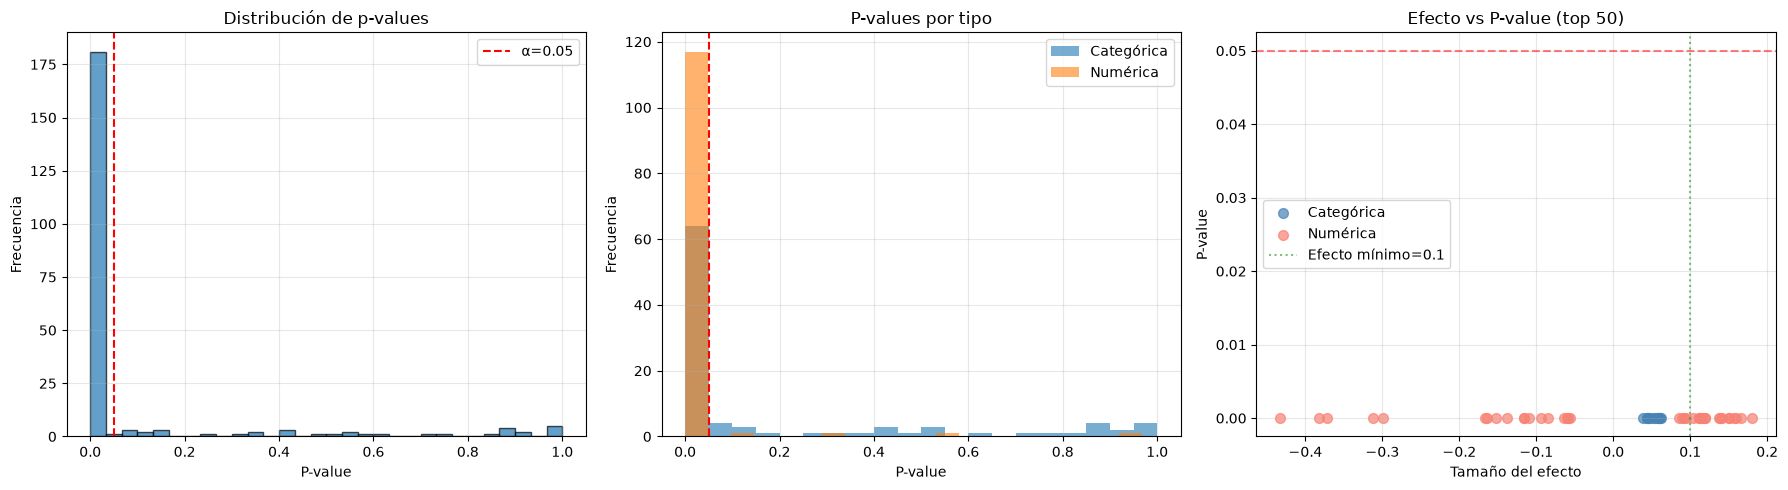

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 8.1 Distribución de p-values
ax = axes[0]
ax.hist(summary_df['P_value'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0.05, color='red', linestyle='--', label='α=0.05')
ax.set_xlabel('P-value')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de p-values')
ax.legend()
ax.grid(alpha=0.3)

# 8.2 P-values por tipo de feature
ax = axes[1]
for tipo in ['Categórica', 'Numérica']:
    subset = summary_df[summary_df['Tipo'] == tipo]['P_value']
    ax.hist(subset, bins=20, alpha=0.6, label=tipo)
ax.axvline(x=0.05, color='red', linestyle='--')
ax.set_xlabel('P-value')
ax.set_ylabel('Frecuencia')
ax.set_title('P-values por tipo')
ax.legend()
ax.grid(alpha=0.3)

# 8.3 Efecto vs P-value (top 50)
ax = axes[2]
top50 = summary_df.nsmallest(50, 'P_value')
colors = {'Categórica': 'steelblue', 'Numérica': 'salmon'}
for tipo in ['Categórica', 'Numérica']:
    subset = top50[top50['Tipo'] == tipo]
    ax.scatter(subset['Effect_size'], subset['P_value'], 
                alpha=0.7, label=tipo, color=colors[tipo], s=50)
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=0.1, color='green', linestyle=':', alpha=0.5, label='Efecto mínimo=0.1')
ax.set_xlabel('Tamaño del efecto')
ax.set_ylabel('P-value')
ax.set_title('Efecto vs P-value (top 50)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

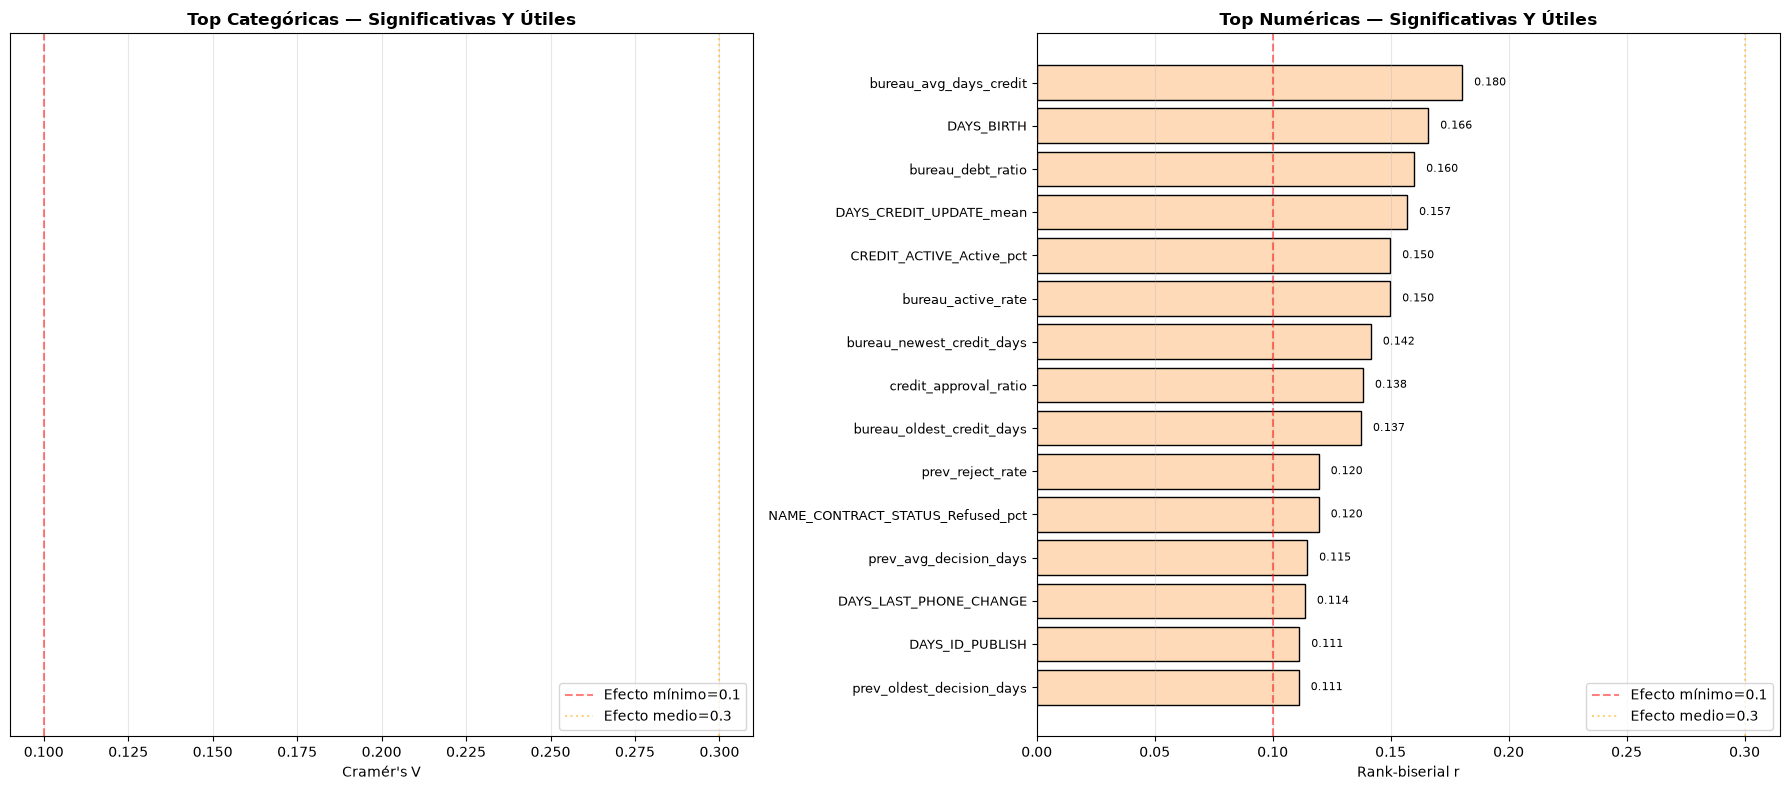

Categóricas útiles: 0
Numéricas útiles:  16


In [17]:
# Top features significativas Y útiles (efecto >= 0.1)
# Izquierda: categóricas | Derecha: numéricas

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Categóricas (izquierda) ---
ax = axes[0]
cat_utiles = summary_df[(summary_df['Tipo'] == 'Categórica') & (summary_df['Util_practica'] == True)]
cat_utiles = cat_utiles.nlargest(15, 'Effect_size')

colors_cat = ['steelblue' if v >= 0.3 else 'lightblue' if v >= 0.2 else 'lightsteelblue' for v in cat_utiles['Effect_size']]
bars = ax.barh(range(len(cat_utiles)), cat_utiles['Effect_size'], color=colors_cat, edgecolor='black')
ax.set_yticks(range(len(cat_utiles)))
ax.set_yticklabels(cat_utiles['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Cramér\'s V')
ax.set_title('Top Categóricas — Significativas Y Útiles', fontsize=12, fontweight='bold')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Efecto mínimo=0.1')
ax.axvline(x=0.3, color='orange', linestyle=':', alpha=0.5, label='Efecto medio=0.3')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, cat_utiles['Effect_size'])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

# --- Numéricas (derecha) ---
ax = axes[1]
num_utiles = summary_df[(summary_df['Tipo'] == 'Numérica') & (summary_df['Util_practica'] == True)]
num_utiles = num_utiles.nlargest(15, 'Effect_size')

colors_num = ['salmon' if v >= 0.3 else 'lightsalmon' if v >= 0.2 else 'peachpuff' for v in num_utiles['Effect_size']]
bars = ax.barh(range(len(num_utiles)), num_utiles['Effect_size'], color=colors_num, edgecolor='black')
ax.set_yticks(range(len(num_utiles)))
ax.set_yticklabels(num_utiles['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Rank-biserial r')
ax.set_title('Top Numéricas — Significativas Y Útiles', fontsize=12, fontweight='bold')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Efecto mínimo=0.1')
ax.axvline(x=0.3, color='orange', linestyle=':', alpha=0.5, label='Efecto medio=0.3')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, num_utiles['Effect_size'])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'Categóricas útiles: {len(summary_df[(summary_df["Tipo"] == "Categórica") & (summary_df["Util_practica"] == True)])}')
print(f'Numéricas útiles:  {len(summary_df[(summary_df["Tipo"] == "Numérica") & (summary_df["Util_practica"] == True)])}')

 Los tests estadísticos miden relación lineal/simple. Voy a usar XGBoost y ese captura relaciones no lineales e interacciones. Entonces no significa que las variables categóricas no me sirven

---
## 9. Guardar resultados

In [18]:
import os
os.makedirs('../data/processed', exist_ok=True)

summary_df.to_csv('../data/processed/statistical_tests_summary.csv', index=False)

print(f'Guardado: data/processed/statistical_tests_summary.csv')
print(f'{len(summary_df)} features evaluadas')
print(f'{len(mantener)} features útiles')
print(f'{len(eliminar)} features a eliminar')

Guardado: data/processed/statistical_tests_summary.csv
217 features evaluadas
16 features útiles
201 features a eliminar


---
## 10. Conclusiones

### ¿Qué se puede ver?


1. Las numéricas dominan
- Categóricas útiles: 0 de 16 (0%)
- Numéricas útiles:   45 de 121 (37%)

Esto sugiere que el dataset es numéricamente dominante. Las variables financieras (ingresos, créditos, scores externos) son los predictores fuertes.

2. Las EXT_SOURCE son las más importantes
- EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 → top en Mann-Whitney y Spearman

Estas son scores de burós de crédito externos. Tienen sentido: son la evaluación de otros expertos.

3. DAYS_BIRTH importa

- r = 0.12, p < 0.001

La edad es un predictor real: a mayor edad, menor probabilidad de default.

4. Muchas features son ruido

- 78 features significativas pero NO útiles
- Con 307K datos, el test detecta diferencias microscópicas. Esas 78 features son estadísticamente reales pero prácticamente inútiles.

5. El desbalance afecta
- 92% paga, 8% default
- Con tan pocos defaulters, es difícil detectar patrones en categóricas con pocas muestras por categoría.
### Próximos pasos

En `07_feature_selection.ipynb`:
1. Eliminamos features no significativas o sin efecto práctico
2. Verificamos multicolinealidad
3. Evaluamos importancia con Random Forest
4. Definimos el set final